In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/Practical 6 Iris Naive Bayes.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


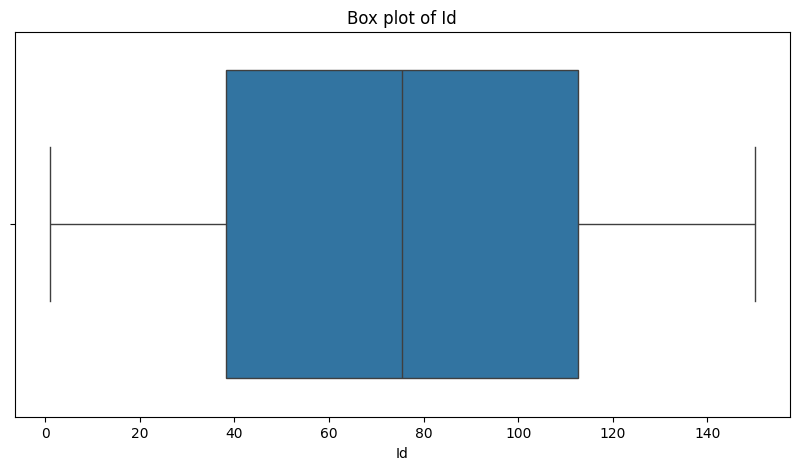

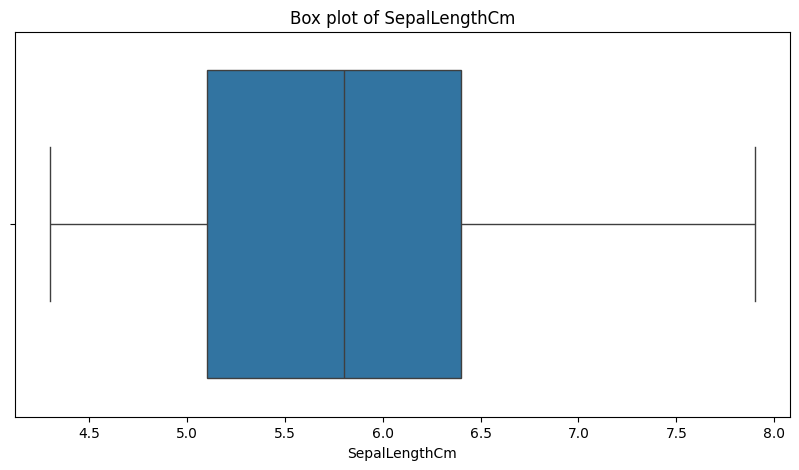

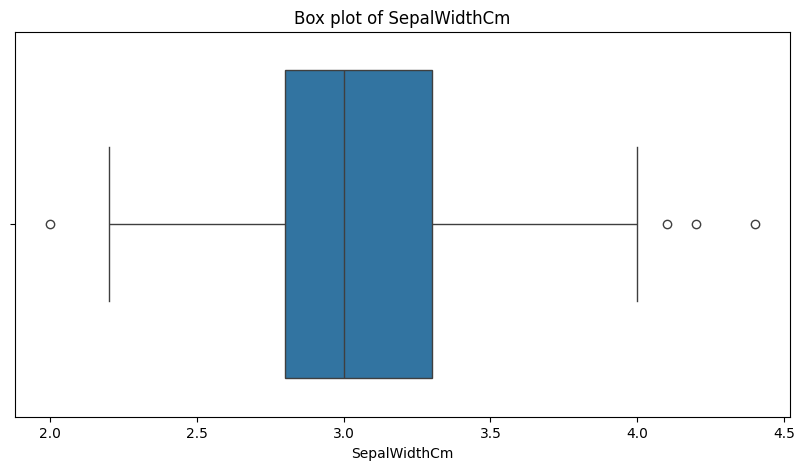

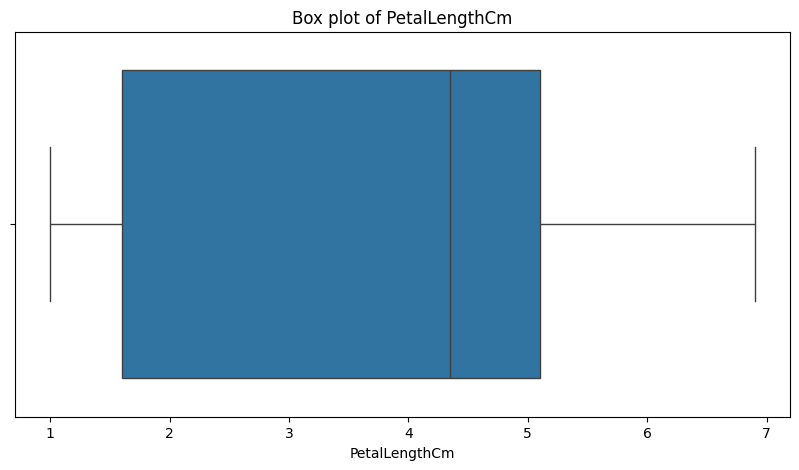

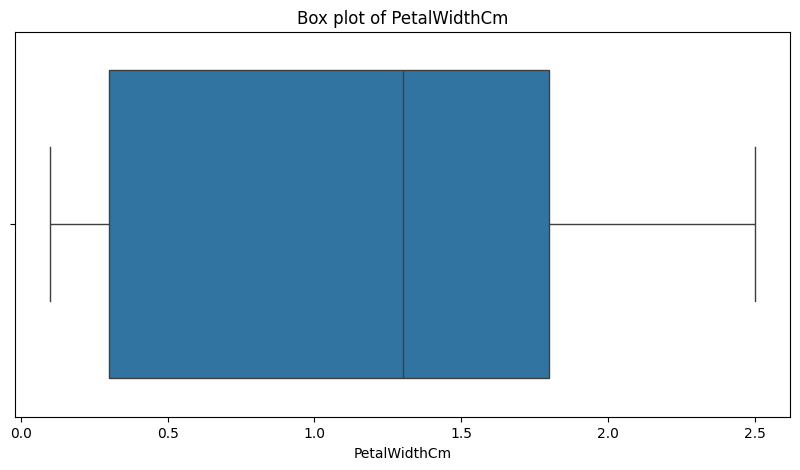

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
for column in df.columns:
  if df[column].dtype in ['float64','int64']:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[column])
    plt.title(f"Box plot of {column}")
    plt.xlabel(column)
    plt.show()

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.93      0.97        15
 Iris-virginica       0.80      1.00      0.89         4

       accuracy                           0.97        30
      macro avg       0.93      0.98      0.95        30
   weighted avg       0.97      0.97      0.97        30



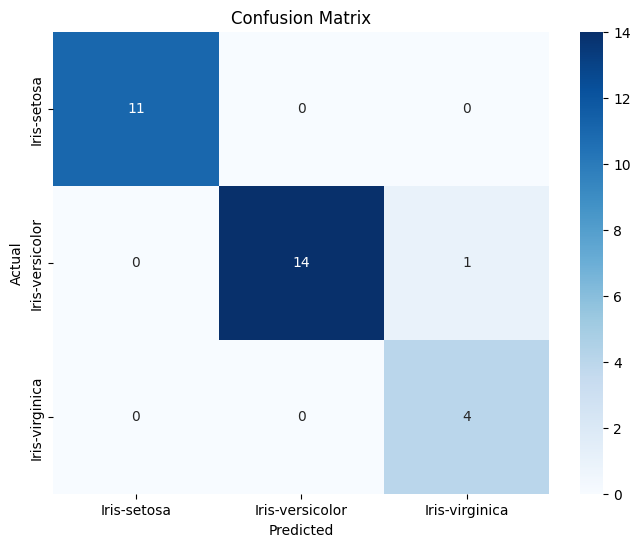

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Label Encoding for Species
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# 2. Define Features (X) and Target (y)
# Dropping 'Id' as it is just an identifier
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=34)

# 4. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Naive Bayes Classification
model = GaussianNB()
model.fit(X_train, y_train)

# 6. Predictions
y_pred = model.predict(X_test)

# 7. Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [7]:
# Detailed Metrics Extraction
tn, fp, fn, tp = cm.ravel()[:4] # Note: ravel() logic depends on class count; for multiclass, we use index-based calculation

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")

Accuracy: 0.9667
Error Rate: 0.0333
